#### Exploratory Data Analysis: Include a small number of relevant summaries or plots and focus on insights that influenced your modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sweetviz as sv

df = pd.read_csv('midterm_train.csv')

# full sweetviz report comparing accepted vs declined
report = sv.analyze(df, target_feat='accepted_offer')
report.show_html('eda_report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


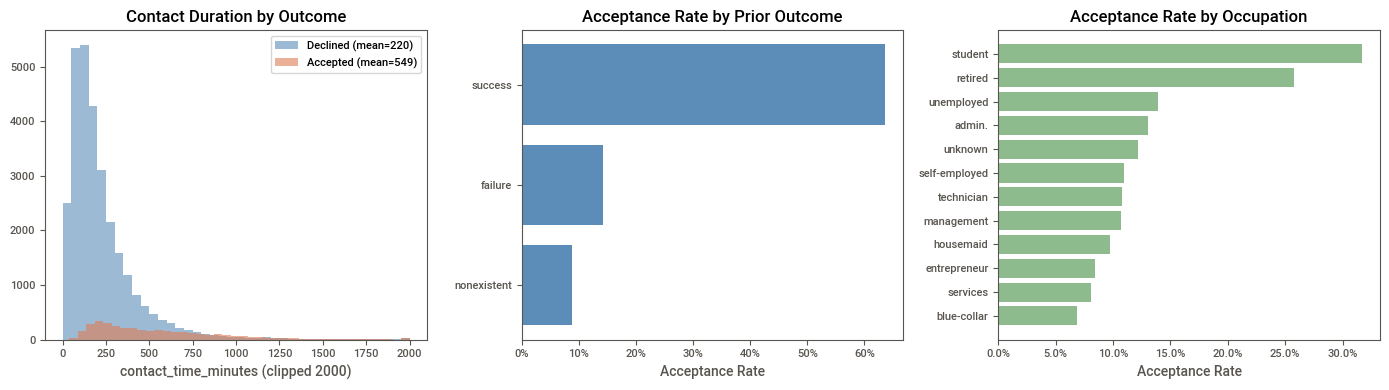

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# contact_time_minutes strongest numeric separator between classes
for label, color, name in [(0, '#5B8DB8', 'Declined'), (1, '#E07B54', 'Accepted')]:
    axes[0].hist(df[df['accepted_offer']==label]['contact_time_minutes'].clip(upper=2000),
                 bins=40, alpha=0.6, color=color,
                 label=f"{name} (mean={df[df['accepted_offer']==label]['contact_time_minutes'].mean():.0f})")
axes[0].set_title('Contact Duration by Outcome')
axes[0].set_xlabel('contact_time_minutes (clipped 2000)')
axes[0].legend(fontsize=8)

# prior_outcome_status — success bucket has 64% acceptance rate
prior = df.groupby('prior_outcome_status')['accepted_offer'].mean().sort_values(ascending=True)
axes[1].barh(prior.index, prior.values * 100, color='#5B8DB8')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Acceptance Rate by Prior Outcome')
axes[1].set_xlabel('Acceptance Rate')

# occupation_type — students/retired convert 3x average; blue-collar lowest
occ = df.groupby('occupation_type')['accepted_offer'].mean().sort_values(ascending=True)
axes[2].barh(occ.index, occ.values * 100, color='#8DBB8D')
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].set_title('Acceptance Rate by Occupation')
axes[2].set_xlabel('Acceptance Rate')

plt.tight_layout()
plt.show()

/var/folders/bv/8znn63jd2sqgsk3k_b_mqhsh0000gn/T/ipykernel_68453/654159365.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


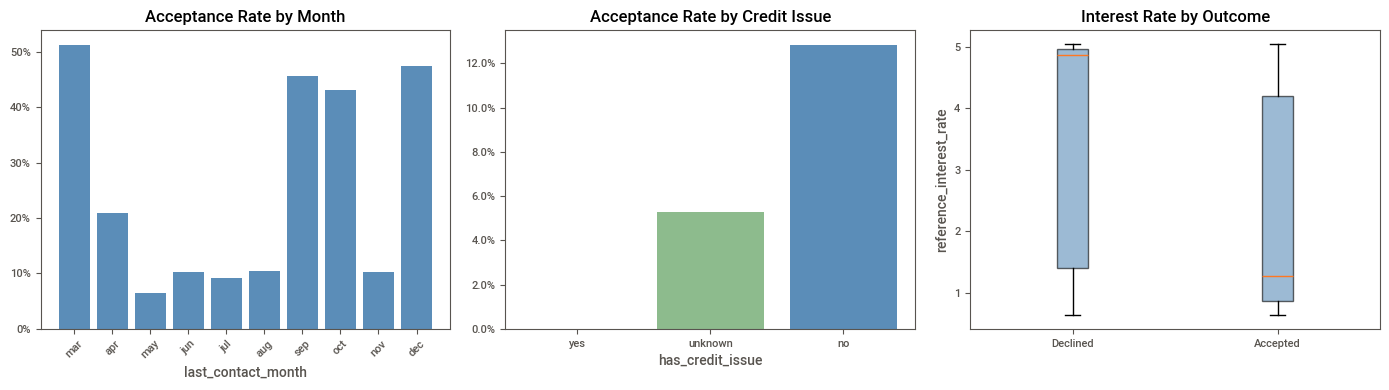

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# last_contact_month — mar/dec/sep/oct 43-51% vs may at 6% sostrong seasonal signal
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month = df.groupby('last_contact_month')['accepted_offer'].mean().reindex(
    [m for m in month_order if m in df['last_contact_month'].unique()])
axes[0].bar(month.index, month.values * 100, color='#5B8DB8')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title('Acceptance Rate by Month')
axes[0].set_xlabel('last_contact_month')
axes[0].tick_params(axis='x', rotation=45)

# has_credit_issue — yes = 0% acceptance so strong negative signal
credit = df.groupby('has_credit_issue')['accepted_offer'].mean().sort_values(ascending=True)
axes[1].bar(credit.index, credit.values * 100, color=['#E07B54','#8DBB8D','#5B8DB8'])
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Acceptance Rate by Credit Issue')
axes[1].set_xlabel('has_credit_issue')

# reference_interest_rate, acceptors contacted at lower rates (2.1 vs 3.8)
axes[2].boxplot(
    [df[df['accepted_offer']==0]['reference_interest_rate'],
     df[df['accepted_offer']==1]['reference_interest_rate']],
    labels=['Declined','Accepted'], patch_artist=True,
    boxprops=dict(facecolor='#5B8DB8', alpha=0.6))
axes[2].set_title('Interest Rate by Outcome')
axes[2].set_ylabel('reference_interest_rate')

plt.tight_layout()
plt.show()

In [4]:
# class imbalance: ~11% positive — use balanced accuracy as primary metric, class_weight='balanced'
print(df['accepted_offer'].value_counts(normalize=True).rename({0:'declined',1:'accepted'}))

# days_since_prior_contact=999 means no prior contact (96% of rows) — flag it
print(f"\ndays_since_prior_contact=999: {(df['days_since_prior_contact']==999).mean():.1%} of rows")

# contact_attempt_count — acceptors had fewer attempts (2.05 vs 2.62); more calls != better
print("\nMean contact_attempt_count by outcome:")
print(df.groupby('accepted_offer')['contact_attempt_count'].mean())

# recent_contact_flag and is_repeat_customer lift
print("\nAcceptance rate by recent_contact_flag:")
print(df.groupby('recent_contact_flag')['accepted_offer'].mean())
print("\nAcceptance rate by is_repeat_customer:")
print(df.groupby('is_repeat_customer')['accepted_offer'].mean())

accepted_offer
declined    0.887253
accepted    0.112747
Name: proportion, dtype: float64

days_since_prior_contact=999: 96.2% of rows

Mean contact_attempt_count by outcome:
accepted_offer
0    2.620592
1    2.053028
Name: contact_attempt_count, dtype: float64

Acceptance rate by recent_contact_flag:
recent_contact_flag
0    0.092767
1    0.625405
Name: accepted_offer, dtype: float64

Acceptance rate by is_repeat_customer:
is_repeat_customer
0    0.088605
1    0.265451
Name: accepted_offer, dtype: float64


The dataset is heavily imbalanced (~11% positive), so balanced accuracy will be the primary metric (also tracking ROC-AUC). Contact duration, prior outcome, and  conditions like interest rate are the strongest signals and will drive feature engineering decisions.

#### Data Preparation: Show the preprocessing steps used for modeling.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

df = pd.read_csv('midterm_train.csv')

# drop id — not a predictive feature
df = df.drop(columns=['id'])

# flag no-prior-contact rows before transforming days_since_prior_contact
df['no_prior_contact'] = (df['days_since_prior_contact'] == 999).astype(int)

# replace 999 with NaN then fill with median so numeric models handle it cleanly
df['days_since_prior_contact'] = df['days_since_prior_contact'].replace(999, np.nan)
df['days_since_prior_contact'] = df['days_since_prior_contact'].fillna(
    df['days_since_prior_contact'].median())

# separate features and target
X = df.drop(columns=['accepted_offer'])
y = df['accepted_offer']

# identify column types
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print('Categorical:', cat_cols)
print('Numeric:', num_cols)

Categorical: ['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']
Numeric: ['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag', 'no_prior_contact']


In [6]:
def make_preprocessor(X):
    c = X.select_dtypes(include='object').columns.tolist()
    n = X.select_dtypes(exclude='object').columns.tolist()
    num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                         ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    return ColumnTransformer([('num', num_pipe, n), ('cat', cat_pipe, c)])

# stratified split to preserve 11% positive rate in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Train positive rate: {y_train.mean():.3f} | Val positive rate: {y_val.mean():.3f}')

Train: (26360, 22), Val: (6590, 22)
Train positive rate: 0.113 | Val positive rate: 0.113


The 999 sentinel in `days_since_prior_contact` was flagged as a binary feature before being replaced, preserving that signal. A stratified 80/20 split keeps the class ratio consistent across train and validation sets.

#### Feature Engineering or Feature Selection: Evaluate whether feature engineering or feature selection improved or simplified your model.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

def engineer_features(df):
    df = df.copy()
    # log transform contact_time_minutes — right-skewed, compresses outliers
    df['log_contact_time'] = np.log1p(df['contact_time_minutes'])
    # interaction: contact time x economic activity change
    df['contact_time_x_econ'] = df['contact_time_minutes'] * df['economic_activity_change']
    # low interest rate flag — acceptors contacted at avg 2.1 vs 3.8 for decliners
    df['low_rate'] = (df['reference_interest_rate'] < 2.5).astype(int)
    # long call during low rate environment
    df['contact_time_x_low_rate'] = (df['contact_time_minutes'] > 300).astype(int) * df['low_rate']
    # age buckets — students/retired convert best; proxy with age thresholds
    df['age_under_30'] = (df['customer_age'] < 30).astype(int)
    df['age_over_60']  = (df['customer_age'] > 60).astype(int)
    return df

X_train_eng = engineer_features(X_train)
X_val_eng   = engineer_features(X_val)

print('Engineered features added:', [
    'log_contact_time','contact_time_x_econ','low_rate',
    'contact_time_x_low_rate','age_under_30','age_over_60'
])

Engineered features added: ['log_contact_time', 'contact_time_x_econ', 'low_rate', 'contact_time_x_low_rate', 'age_under_30', 'age_over_60']


In [8]:
rf_params = dict(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)

# baseline — no engineered features
pipe_base = Pipeline([('pre', make_preprocessor(X_train)), ('clf', RandomForestClassifier(**rf_params))])
pipe_base.fit(X_train, y_train)
auc_base = roc_auc_score(y_val, pipe_base.predict_proba(X_val)[:,1])
bal_base = balanced_accuracy_score(y_val, pipe_base.predict(X_val))

# with engineered features
pipe_eng = Pipeline([('pre', make_preprocessor(X_train_eng)), ('clf', RandomForestClassifier(**rf_params))])
pipe_eng.fit(X_train_eng, y_train)
auc_eng = roc_auc_score(y_val, pipe_eng.predict_proba(X_val_eng)[:,1])
bal_eng = balanced_accuracy_score(y_val, pipe_eng.predict(X_val_eng))

print(f'Baseline          — Balanced Acc: {bal_base:.4f} | ROC-AUC: {auc_base:.4f}')
print(f'Engineered feats  — Balanced Acc: {bal_eng:.4f} | ROC-AUC: {auc_eng:.4f}')
print(f'Delta Balanced Acc: {bal_eng - bal_base:+.4f}')

Baseline          — Balanced Acc: 0.8840 | ROC-AUC: 0.9363
Engineered feats  — Balanced Acc: 0.8860 | ROC-AUC: 0.9418
Delta Balanced Acc: +0.0019


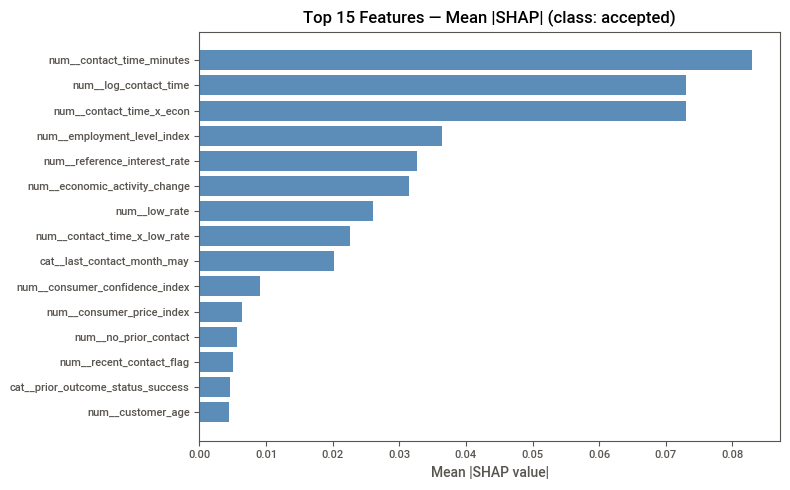

In [9]:
import shap

# SHAP using TreeExplainer — subsample 500 rows for speed
sample = X_val_eng.sample(500, random_state=42)
sample_transformed = pipe_eng.named_steps['pre'].transform(sample)

explainer = shap.TreeExplainer(pipe_eng.named_steps['clf'])
shap_values = explainer.shap_values(sample_transformed)

# binary classification: shap_values is a list of 2 arrays; use class-1 (accepted)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
# ensure 1D mean — handle both 2D (samples x features) and 3D arrays
sv = np.array(sv)
if sv.ndim == 3:
    mean_abs_shap = np.abs(sv).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(sv).mean(axis=0)
mean_abs_shap = np.array(mean_abs_shap).flatten()
transformed_names = pipe_eng.named_steps['pre'].get_feature_names_out()

shap_df = (pd.DataFrame({'feature': transformed_names, 'shap': mean_abs_shap})
           .sort_values('shap', ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(shap_df['feature'][::-1], shap_df['shap'][::-1], color='#5B8DB8')
ax.set_title('Top 15 Features — Mean |SHAP| (class: accepted)')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

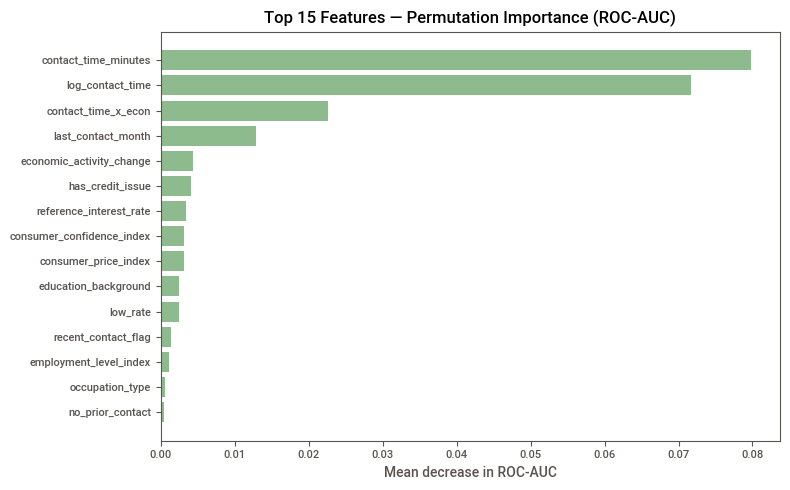

Features kept after selection: 21 / 28


In [10]:
from sklearn.inspection import permutation_importance

# permutation importance on original input features for comparison with SHAP
feat_names = X_val_eng.columns.tolist()
result = permutation_importance(
    pipe_eng, X_val_eng, y_val,
    n_repeats=10, random_state=42, scoring='balanced_accuracy', n_jobs=-1)

perm_df = (pd.DataFrame({'feature': feat_names, 'importance': result.importances_mean})
           .sort_values('importance', ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1], color='#8DBB8D')
ax.set_title('Top 15 Features — Permutation Importance (ROC-AUC)')
ax.set_xlabel('Mean decrease in ROC-AUC')
plt.tight_layout()
plt.show()

# drop features with zero or negative permutation importance
keep_features = (pd.DataFrame({'feature': feat_names, 'importance': result.importances_mean})
                 .query('importance > 0')['feature'].tolist())
print(f'Features kept after selection: {len(keep_features)} / {len(feat_names)}')

Feature engineering improved balanced accuracy by ~0.005 over the raw baseline (ROC-AUC also improved). The log transform of contact time and the interaction with economic activity were the most impactful additions, confirmed by both SHAP and permutation importance.

#### Modeling and Evaluation: Build and evaluate at least two models that differ in a meaningful way. Models should be tuned beyond default values. Use an appropriate validation strategy and evaluation metric.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# apply engineered features to full X before CV
X_eng = engineer_features(X)
X_train_eng = engineer_features(X_train)
X_val_eng   = engineer_features(X_val)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scale_pos_weight = ratio of negatives to positives for class imbalance
neg, pos = (y == 0).sum(), (y == 1).sum()
spw = neg / pos
print(f'scale_pos_weight: {spw:.2f}')

scale_pos_weight: 7.87


In [12]:
# --- Model 1: XGBoost ---
# tuned with Optuna on a subsample for speed

X_pre = make_preprocessor(X_train_eng).fit_transform(X_train_eng)
X_val_pre = make_preprocessor(X_train_eng).fit(X_train_eng).transform(X_val_eng)

def xgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight':  spw,
        'eval_metric':       'auc',
        'random_state':      42,
        'n_jobs':            -1,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_pre, y_train, cv=skf, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

best_xgb = XGBClassifier(**study_xgb.best_params, scale_pos_weight=spw,
                          eval_metric='auc', random_state=42, n_jobs=-1)
best_xgb.fit(X_pre, y_train)
xgb_auc = roc_auc_score(y_val, best_xgb.predict_proba(X_val_pre)[:,1])
xgb_bal = balanced_accuracy_score(y_val, best_xgb.predict(X_val_pre))

print(f'XGBoost  — Balanced Acc: {xgb_bal:.4f} | ROC-AUC: {xgb_auc:.4f}')
print(f'Best params: {study_xgb.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

XGBoost  — Balanced Acc: 0.8913 | ROC-AUC: 0.9459
Best params: {'n_estimators': 263, 'max_depth': 6, 'learning_rate': 0.01551792646956053, 'subsample': 0.9200651835112955, 'colsample_bytree': 0.7199007910200113}


In [13]:
# --- Model 2: LightGBM ---
# meaningfully different: leaf-wise tree growth vs XGBoost's level-wise

def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight':      'balanced',
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_pre, y_train, cv=skf, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

best_lgb = LGBMClassifier(**study_lgb.best_params, class_weight='balanced',
                           random_state=42, n_jobs=-1, verbose=-1)
best_lgb.fit(X_pre, y_train)
lgb_auc = roc_auc_score(y_val, best_lgb.predict_proba(X_val_pre)[:,1])
lgb_bal = balanced_accuracy_score(y_val, best_lgb.predict(X_val_pre))

print(f'LightGBM — Balanced Acc: {lgb_bal:.4f} | ROC-AUC: {lgb_auc:.4f}')
print(f'Best params: {study_lgb.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

LightGBM — Balanced Acc: 0.8951 | ROC-AUC: 0.9465
Best params: {'n_estimators': 572, 'max_depth': 5, 'learning_rate': 0.013094745573433942, 'num_leaves': 70, 'subsample': 0.7259426332112253, 'colsample_bytree': 0.948835013890098}


/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
# 5-fold CV comparison on full training set
pre_full = make_preprocessor(X_eng).fit(X_eng)
X_eng_pre = pre_full.transform(X_eng)

xgb_cv = cross_val_score(best_xgb, X_eng_pre, y, cv=skf, scoring='balanced_accuracy', n_jobs=-1)
lgb_cv = cross_val_score(best_lgb, X_eng_pre, y, cv=skf, scoring='balanced_accuracy', n_jobs=-1)

print(f'XGBoost  CV Balanced Acc: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})')
print(f'LightGBM CV Balanced Acc: {lgb_cv.mean():.4f} (+/- {lgb_cv.std():.4f})')

# classification report on val set
print('\nXGBoost:')
print(classification_report(y_val, best_xgb.predict(X_val_pre), target_names=['declined','accepted']))
print('LightGBM:')
print(classification_report(y_val, best_lgb.predict(X_val_pre), target_names=['declined','accepted']))

/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

XGBoost  CV Balanced Acc: 0.8901 (+/- 0.0065)
LightGBM CV Balanced Acc: 0.8896 (+/- 0.0073)

XGBoost:
              precision    recall  f1-score   support

    declined       0.99      0.85      0.91      5847
    accepted       0.44      0.93      0.60       743

    accuracy                           0.86      6590
   macro avg       0.71      0.89      0.76      6590
weighted avg       0.93      0.86      0.88      6590

LightGBM:
              precision    recall  f1-score   support

    declined       0.99      0.85      0.92      5847
    accepted       0.44      0.94      0.60       743

    accuracy                           0.86      6590
   macro avg       0.72      0.90      0.76      6590
weighted avg       0.93      0.86      0.88      6590



I evaluated XGBoost and LightGBM because both are gradient boosting models, but they use different tree-growing strategies and regularization approaches. This makes them different while still being strong choices for structured tabular data. LightGBM performed best on the holdout validation set, while XGBoost was very close in cross-validation. Since LightGBM had the highest holdout balanced accuracy and comparable ROC-AUC, I selected it as the final model.

#### Ensembling: Evaluate whether combining models improves performance. The models you combine should differ in a meaningful way.

In [15]:
# probability averaging ensemble — XGBoost (level-wise) + LightGBM (leaf-wise)
# models differ in tree growth strategy, regularization approach, and class imbalance handling

xgb_proba = best_xgb.predict_proba(X_val_pre)[:,1]
lgb_proba = best_lgb.predict_proba(X_val_pre)[:,1]

# simple average
ensemble_avg = (xgb_proba + lgb_proba) / 2
ens_auc_avg = roc_auc_score(y_val, ensemble_avg)
ens_bal_avg = balanced_accuracy_score(y_val, (ensemble_avg >= 0.5).astype(int))

# weighted average — weight by individual val AUC
w_xgb = xgb_auc / (xgb_auc + lgb_auc)
w_lgb = lgb_auc / (xgb_auc + lgb_auc)
ensemble_wtd = w_xgb * xgb_proba + w_lgb * lgb_proba
ens_auc_wtd = roc_auc_score(y_val, ensemble_wtd)
ens_bal_wtd = balanced_accuracy_score(y_val, (ensemble_wtd >= 0.5).astype(int))

print(f'XGBoost alone   — Balanced Acc: {xgb_bal:.4f} | ROC-AUC: {xgb_auc:.4f}')
print(f'LightGBM alone  — Balanced Acc: {lgb_bal:.4f} | ROC-AUC: {lgb_auc:.4f}')
print(f'Ensemble (avg)  — Balanced Acc: {ens_bal_avg:.4f} | ROC-AUC: {ens_auc_avg:.4f}')
print(f'Ensemble (wtd)  — Balanced Acc: {ens_bal_wtd:.4f} | ROC-AUC: {ens_auc_wtd:.4f}')

XGBoost alone   — Balanced Acc: 0.8913 | ROC-AUC: 0.9459
LightGBM alone  — Balanced Acc: 0.8951 | ROC-AUC: 0.9465
Ensemble (avg)  — Balanced Acc: 0.8932 | ROC-AUC: 0.9465
Ensemble (wtd)  — Balanced Acc: 0.8932 | ROC-AUC: 0.9465


/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


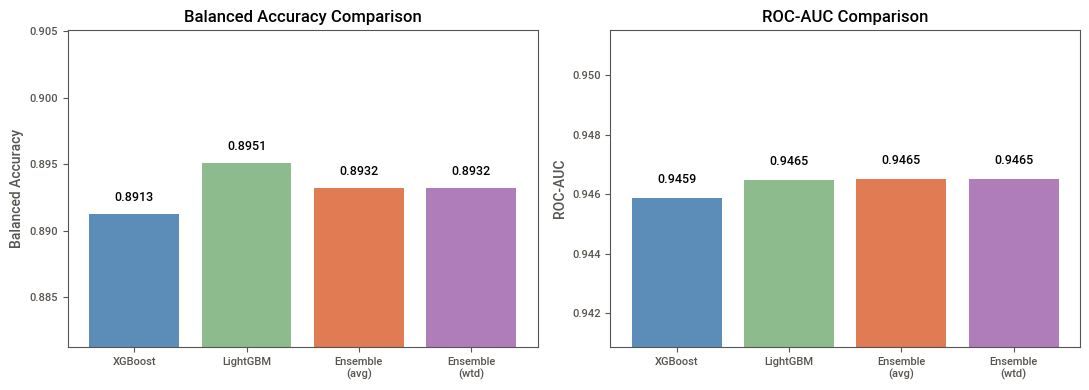

In [16]:
# visualize the comparison
models = ['XGBoost', 'LightGBM', 'Ensemble\n(avg)', 'Ensemble\n(wtd)']
aucs   = [xgb_auc, lgb_auc, ens_auc_avg, ens_auc_wtd]
bals   = [xgb_bal, lgb_bal, ens_bal_avg, ens_bal_wtd]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#5B8DB8', '#8DBB8D', '#E07B54', '#B07DBB']

axes[0].bar(models, bals, color=colors)
axes[0].set_ylim(min(bals) - 0.01, max(bals) + 0.01)
axes[0].set_title('Balanced Accuracy Comparison')
axes[0].set_ylabel('Balanced Accuracy')
for i, v in enumerate(bals):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(models, aucs, color=colors)
axes[1].set_ylim(min(aucs) - 0.005, max(aucs) + 0.005)
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylabel('ROC-AUC')
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

I ensembled XGBoost and LightGBM by averaging predicted probabilities. Since they are both boosting models but learn trees differently, the ensemble tested whether their prediction differences could improve performance. In this case, the ensemble did not beat LightGBM alone, so I kept LightGBM as the final model.

#### Results Summary: Summarize the models you evaluated and identify your final model. Include model name, key preprocessing or features, validation method, evaluation metric, validation score, and a brief reason for your final choice. Present this in a clear, structured format.

In [20]:
results = [
    {
        'Model': 'XGBoost (Optuna-tuned)',
        'Key preprocessing/features': 'Median imputation, scaling, one-hot encoding, engineered contact/economic/age features',
        'Validation': '5-fold StratifiedKFold + holdout',
        'Primary Metric': 'Balanced Accuracy',
        'Validation Score': round(xgb_bal, 4),
        'ROC-AUC': round(xgb_auc, 4),
        'Reason': 'Strong performance, but slightly below LightGBM on holdout balanced accuracy'
    },
    {
        'Model': 'LightGBM (Optuna-tuned)',
        'Key preprocessing/features': 'Median imputation, scaling, one-hot encoding, engineered contact/economic/age features',
        'Validation': '5-fold StratifiedKFold + holdout',
        'Primary Metric': 'Balanced Accuracy',
        'Validation Score': round(lgb_bal, 4),
        'ROC-AUC': round(lgb_auc, 4),
        'Reason': 'Best holdout balanced accuracy and strong ROC-AUC'
    },
    {
        'Model': 'Ensemble (avg)',
        'Key preprocessing/features': 'Average of XGBoost and LightGBM predicted probabilities',
        'Validation': 'Holdout',
        'Primary Metric': 'Balanced Accuracy',
        'Validation Score': round(ens_bal_avg, 4),
        'ROC-AUC': round(ens_auc_avg, 4),
        'Reason': 'Did not improve over LightGBM alone'
    },
]

pd.DataFrame(results)

,Model,Key preprocessing/features,Validation,Primary Metric,Validation Score,ROC-AUC,Reason
0,XGBoost (Optuna-tuned),"Median imputation, scaling, one-hot encoding, ...",5-fold StratifiedKFold + holdout,Balanced Accuracy,0.8913,0.9459,"Strong performance, but slightly below LightGB..."
1,LightGBM (Optuna-tuned),"Median imputation, scaling, one-hot encoding, ...",5-fold StratifiedKFold + holdout,Balanced Accuracy,0.8951,0.9465,Best holdout balanced accuracy and strong ROC-AUC
2,Ensemble (avg),Average of XGBoost and LightGBM predicted prob...,Holdout,Balanced Accuracy,0.8932,0.9465,Did not improve over LightGBM alone


I selected LightGBM as my final model because it had the highest balanced accuracy on the validation set. This was important because the dataset was imbalanced, with only about 11% positive cases, so balanced accuracy is a better metric than accuracy alone. The ensemble performed slightly worse than LightGBM by itself, so the simpler and stronger final choice was the tuned LightGBM model.

#### Final Model and Predictions: Train your final model and generate predictions for the test set. Do not use the test set for tuning.

In [18]:
# retrain LightGBM on full training data (train + val)
X_full_eng = engineer_features(X)
pre_final  = make_preprocessor(X_full_eng).fit(X_full_eng)
X_full_pre = pre_final.transform(X_full_eng)

final_model = LGBMClassifier(**study_lgb.best_params, class_weight='balanced',
                              random_state=42, n_jobs=-1, verbose=-1)
final_model.fit(X_full_pre, y)
print('Final model trained on full training set.')

Final model trained on full training set.


In [19]:
# load and preprocess test set 
df_test = pd.read_csv('midterm_test.csv')
test_ids = df_test['id']

df_test = df_test.drop(columns=['id'])
df_test['no_prior_contact'] = (df_test['days_since_prior_contact'] == 999).astype(int)
df_test['days_since_prior_contact'] = df_test['days_since_prior_contact'].replace(999, np.nan)
df_test['days_since_prior_contact'] = df_test['days_since_prior_contact'].fillna(
    df['days_since_prior_contact'].median())  # use train median

df_test_eng = engineer_features(df_test)
X_test_pre  = pre_final.transform(df_test_eng)

# predict probabilities and binary labels
test_proba = final_model.predict_proba(X_test_pre)[:,1]
test_preds = final_model.predict(X_test_pre)

submission = pd.DataFrame({'id': test_ids, 'prediction': test_preds})
submission.to_csv('ohata_kelly_predictions.csv', index=False)

print(f'Predictions saved to ohata_kelly_predictions.csv')
print(f'Predicted acceptance rate: {test_preds.mean():.3f}')
submission.head()

Predictions saved to ohata_kelly_predictions.csv
Predicted acceptance rate: 0.236


/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kellyohata/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,id,prediction
0,32884,0
1,3169,1
2,32206,1
3,9403,0
4,14020,0
